In [1]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
import os
import json
import pandas as pd

# 1) Discover & sort shrink_train directories
dirs = sorted(
    [d for d in os.listdir('.') 
     if os.path.isdir(d) and d.startswith('shrink_train_')],
    # extract the number after the second underscore
    key=lambda x: int(x.split('_')[2])
)

# 2) Collect metrics into a list of dicts
records = []
for d in dirs:
    metrics_path = os.path.join(d, 'performance_metrics.json')
    if not os.path.exists(metrics_path):
        print(f"Warning: no metrics in {d}, skipping")
        continue

    with open(metrics_path, 'r') as f:
        metrics = json.load(f)

    # parse out N
    N = int(d.split('_')[2])
    rec = {'N_removed': N}

    # flatten output_1 and output_2 metrics
    for output in ['output_1', 'output_2']:
        for m in ['r2', 'mae', 'mape', 'rmse', 'rmspe']:
            rec[f"{output}_{m}"] = metrics.get(output, {}).get(m, None)

    records.append(rec)

# 3) Build and sort DataFrame
df = pd.DataFrame(records)
df = df.sort_values('N_removed').reset_index(drop=True)
df['N_sensors'] = df['N_removed'].iloc[::-1].values
df

,N_removed,output_1_r2,output_1_mae,output_1_mape,output_1_rmse,output_1_rmspe,output_2_r2,output_2_mae,output_2_mape,output_2_rmse,output_2_rmspe,N_sensors
0,1,0.996882,6.863277,2.777307,10.322411,5.651590,0.980836,16.398512,11.874323,20.914862,16.440523,61
1,2,0.990726,13.624240,5.254050,17.803638,7.614426,0.992005,10.789503,10.552701,13.509312,17.677501,60
2,3,0.992732,12.993052,7.873712,15.760780,11.572685,0.993934,6.878451,5.762314,11.767374,12.422143,59
3,4,0.994520,7.832782,3.633031,13.685391,6.859969,0.979495,16.261772,20.116737,21.634371,30.879200,58
4,5,0.990689,13.182304,7.587389,17.839357,11.460842,0.984685,15.305120,21.521719,18.696877,34.997919,57
...,...,...,...,...,...,...,...,...,...,...,...,...
56,57,0.789894,50.920219,29.931766,84.740021,58.512962,0.584548,37.786728,11.861444,97.381271,20.232928,5
57,58,0.481835,71.147514,21.145710,133.077271,28.745681,-0.082896,84.945793,29.983273,157.220123,39.144948,4
58,59,0.378708,113.487335,71.236521,145.719528,109.229171,-0.564366,118.785912,48.716030,188.966125,57.348639,3
59,60,0.366292,106.505150,62.781644,147.168381,97.752404,-0.602097,121.387520,50.503176,191.231415,58.947897,2


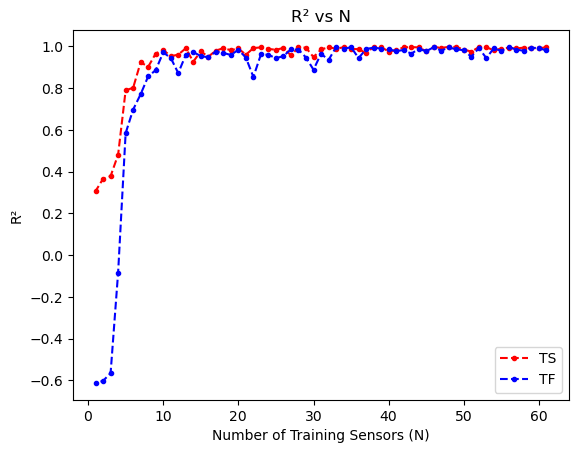

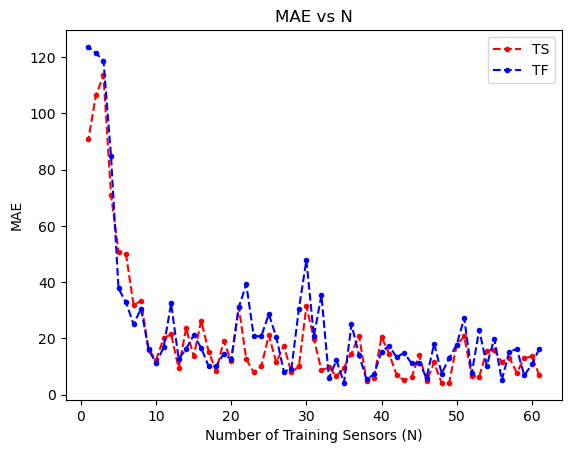

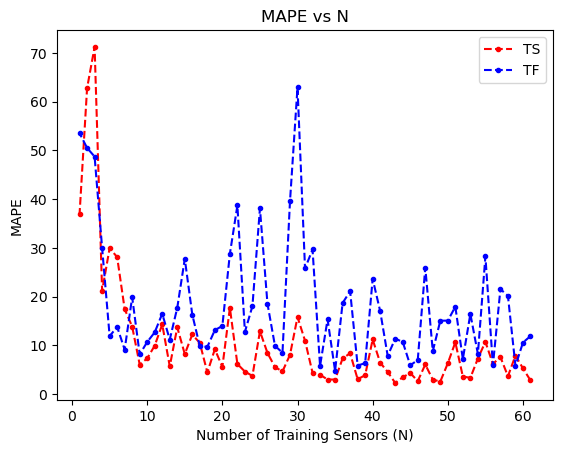

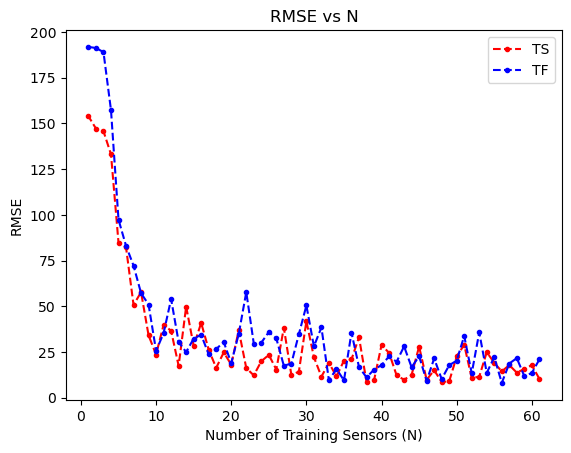

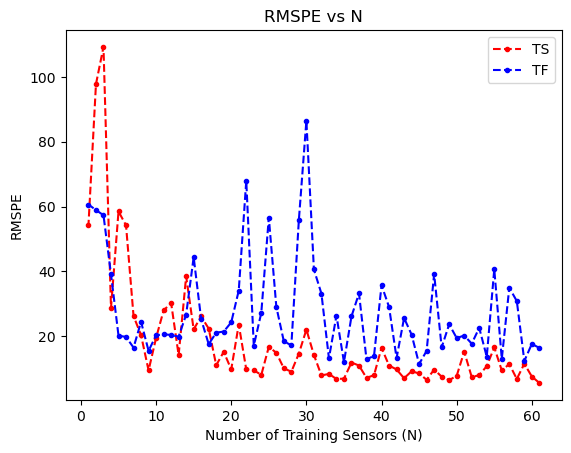

In [11]:
# Plot each metric vs. N
for metric in ['r2', 'mae', 'mape', 'rmse', 'rmspe']:
    plt.figure()
    plt.plot(df['N_sensors'], df[f'output_1_{metric}'], '--o', color='r',label='TS', markersize=3)
    plt.plot(df['N_sensors'], df[f'output_2_{metric}'], '--o', color='b',label='TF',  markersize=3)
    plt.xlabel('Number of Training Sensors (N)')
    ylabel = 'R\u00b2' if metric == 'r2' else metric.upper()
    plt.ylabel(ylabel)
    plt.title(f"{ylabel} vs N")
    plt.legend()
    plt.show()

In [7]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

# 1) Discover & sort shrink_train directories
dirs = sorted(
    [d for d in os.listdir('.') 
     if os.path.isdir(d) and d.startswith('shrink_train_')],
    # extract the number after the second underscore
    key=lambda x: int(x.split('_')[2])
)

# Load all runs
runs = []
for d in dirs:
    N = int(d.split('_')[2])
    tfile = os.path.join(d, 'Ytrue_rescaled.npy')
    pfile = os.path.join(d, 'Ypred_rescaled.npy')
    if os.path.exists(tfile) and os.path.exists(pfile):
        Ytrue = np.load(tfile)
        Ypred = np.load(pfile)
        runs.append((N, Ytrue, Ypred))

# Sample every 20th run (or choose your sampling interval)
sampled = runs[::5]
if not sampled:
    raise RuntimeError("No valid runs found to plot.")

# Set fixed x-axis endpoint
x_end = 340070

# Prepare colormap from blue → red
cmap = cm.get_cmap('coolwarm', len(sampled))

# Plot outputs 1 and 2 separately
for out_idx in [0, 1]:
    plt.figure(figsize=(16, 6))

    for i, (N, Ytrue, Ypred) in enumerate(sampled):
        length = len(Ypred)
        offset = x_end - length
        x_vals = np.arange(offset, offset + length)

        # true series: first run bold, others faded
        if i == 0:
            plt.plot(x_vals, Ytrue[:, out_idx],
                     color='black', linewidth=2, label='True')
        else:
            plt.plot(x_vals, Ytrue[:, out_idx],
                     color='black', linewidth=1, alpha=0.3)

        # predicted series: dashed, colored by N
        plt.plot(x_vals, Ypred[:, out_idx],
                 '--', color=cmap(i), alpha=1, label=f"Pred N={N} removed")

    plt.xlabel('Time Step')
    ylabel = 'TS' if out_idx == 0 else 'TF'
    plt.ylabel('Temperature (°C)')
    plt.title(f"True vs Predicted for {ylabel} (every 5th N, aligned end)")
    plt.xlim(x_end - 20*5485, x_end)
    plt.ylim(0, 1200)
    plt.legend(ncol=3)
    
    # vertical sensor boundaries
    for x_val in np.arange(5485, x_end, 5485):
        plt.vlines(x=x_val, ymin=-100, ymax=1500,
                   color='gray', linestyle='--',
                   linewidth=0.5, alpha=0.5)
    
    plt.tight_layout()
    plt.show()


RuntimeError: No valid runs found to plot.

C:\Users\Logan\AppData\Local\Temp\ipykernel_8072\3132307583.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('coolwarm', len(sampled))


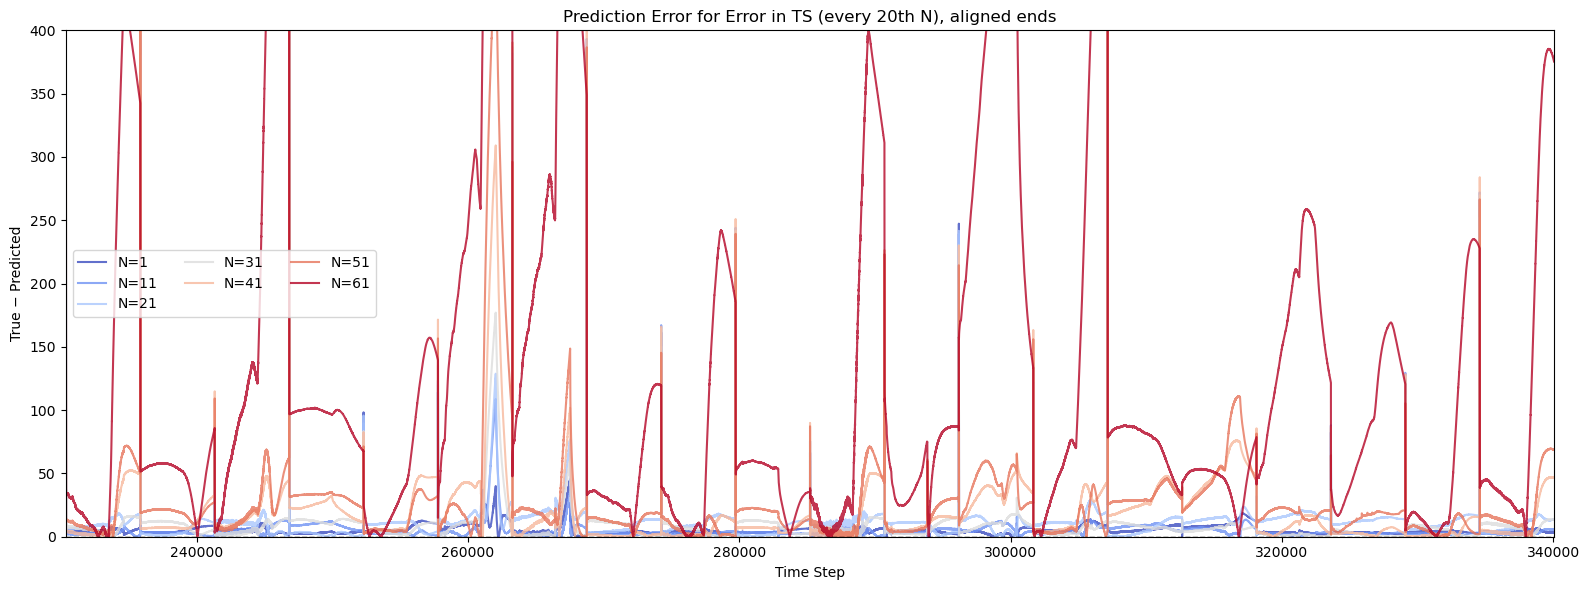

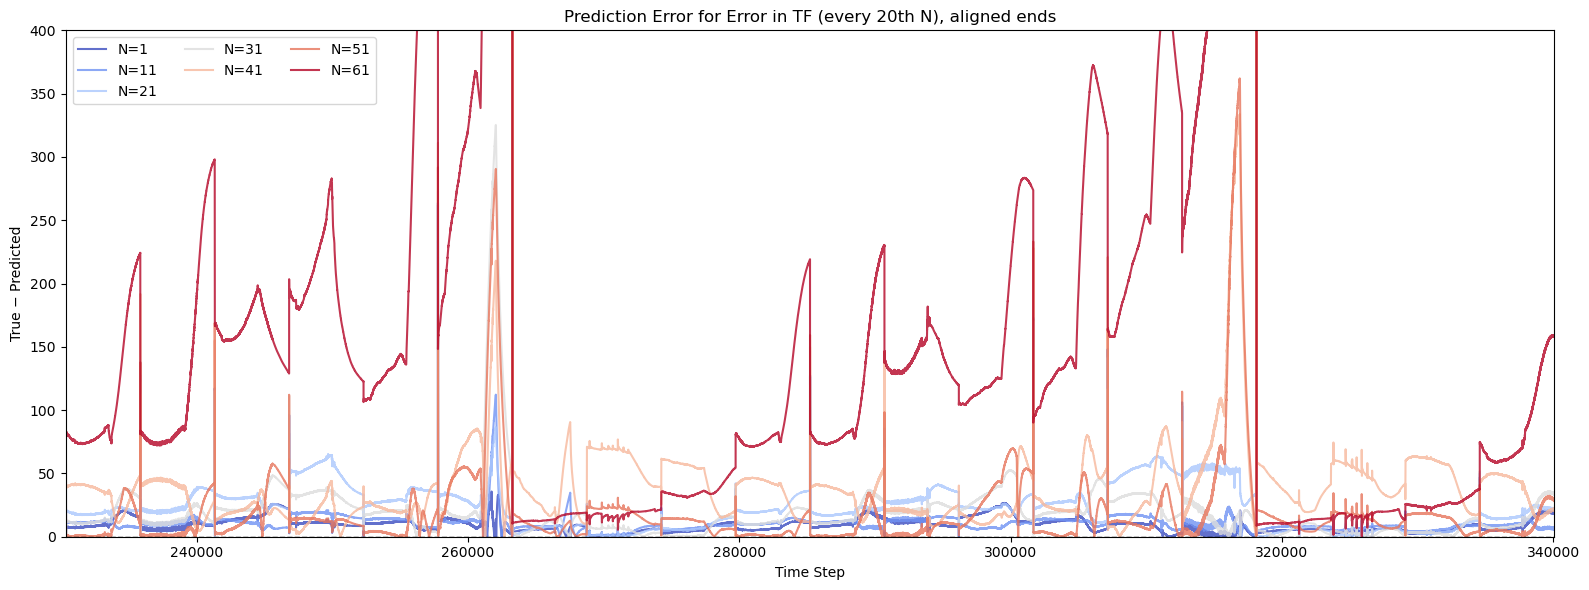

In [33]:
# # 1) Gather & sort your reallocate directories
# dirs = sorted(
#     [d for d in os.listdir('.') if os.path.isdir(d) and d.startswith('reallocate_')],
#     key=lambda x: int(x.split('_')[1])
# )

# # 2) Load all runs
# runs = []
# for d in dirs:
#     N = int(d.split('_')[1])
#     tfile = os.path.join(d, 'Ytrue_rescaled.npy')
#     pfile = os.path.join(d, 'Ypred_rescaled.npy')
#     if os.path.exists(tfile) and os.path.exists(pfile):
#         Ytrue = np.load(tfile)
#         Ypred = np.load(pfile)
#         runs.append((N, Ytrue, Ypred))

# 3) Sample every 20th run (or change the interval)
sampled = runs[::10]
if not sampled:
    raise RuntimeError("No valid runs found to plot.")

# 4) Fixed x-axis endpoint
x_end = 340070

# 5) Prepare colormap from blue → red
cmap = cm.get_cmap('coolwarm', len(sampled))

# 6) Plot error (true - pred) separately for each output
for out_idx in [0, 1]:
    plt.figure(figsize=(16, 6))

    for i, (N, Ytrue, Ypred) in enumerate(sampled):
        length = len(Ypred)
        offset = x_end - length
        x_vals = np.arange(offset, offset + length)

        # compute error: true minus predicted
        error = np.abs(Ytrue[:, out_idx] - Ypred[:, out_idx])

        # plot error curve
        plt.plot(x_vals, error,
                 color=cmap(i), alpha=0.8,
                 label=f"N={N}")

    # zero line
    plt.axhline(0, color='black', linewidth=1, linestyle='--')

    plt.xlabel('Time Step')
    ylabel = 'Error in TS' if out_idx == 0 else 'Error in TF'
    plt.ylabel('True − Predicted')
    plt.title(f'Prediction Error for {ylabel} (every 20th N), aligned ends')
    plt.legend(ncol=3)
    plt.xlim(x_end - 20*5485, x_end)
    plt.ylim(0,400)
    #plt.yscale('log')
    plt.tight_layout()
    plt.show()